In [5]:
import sys
sys.path.insert(0, '..')
import pckEDA as mf
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set(color_codes=True)

In [6]:
eda = mf.AnalisisDatosExploratorio("../datasets/hotel_bookings.csv", 1)
eda.mostrarTamaño()
eda.muestraPrimerosValores(5)

Tamaño del DataFrame: (408, 20)
Primeros 5 valores:               hotel  is_canceled  lead_time arrival_date_month  \
16303    City Hotel            1         67                May   
17344    City Hotel            1        224               June   
4890   Resort Hotel            0         76            January   
11142  Resort Hotel            0         72               July   
18700    City Hotel            1        229               July   

       stays_in_weekend_nights  stays_in_week_nights  adults  children  \
16303                        0                     3       2         0   
17344                        0                     2       2         0   
4890                         1                     3       2         0   
11142                        0                     2       2         0   
18700                        1                     4       2         0   

       babies  previous_cancellations  previous_bookings_not_canceled  \
16303       0                    

In [8]:
eda.muestraTiposDeDatos()

hotel                           object
is_canceled                      int64
lead_time                        int64
arrival_date_month              object
stays_in_weekend_nights          int64
                                ...   
customer_type                   object
adr                            float64
required_car_parking_spaces      int64
total_of_special_requests        int64
reservation_status              object
Length: 20, dtype: object


In [9]:
# --- Encoding de columnas categóricas ---
#
# Modo 1: Label encoding automático
#   Asigna un entero a cada categoría en orden alfabético (0, 1, 2...).
#   Útil cuando las categorías NO tienen un orden o jerarquía definida.
#   Ejemplo: "City Hotel" → 0, "Resort Hotel" → 1
eda.codificarCategorica("hotel")

# Modo 2: Mapeo personalizado (tipo enum / ordinal)
#   El usuario define qué valor numérico corresponde a cada categoría.
#   Útil cuando las categorías SÍ tienen un orden lógico o significado
#   específico que debe reflejarse en el número asignado.
#   Ejemplo: sin depósito = 0, no reembolsable = 1, reembolsable = 2
eda.codificarCategorica("deposit_type", mapeo={
    "No Deposit": 0,
    "Non Refund": 1,
    "Refundable": 2
})

Columna 'hotel' codificada con el mapeo:
  City Hotel → 0
  Resort Hotel → 1
Columna 'deposit_type' codificada con el mapeo:
  No Deposit → 0
  Non Refund → 1
  Refundable → 2


In [11]:
eda.eliminarColumnas(['arrival_date_month', 'assigned_room_type',
                       'reservation_status', 'customer_type'])
eda.mostrarTamaño()

Tamaño del DataFrame: (408, 16)


In [13]:
eda.renombrarColumnas(
    ["is_canceled", "lead_time", "stays_in_weekend_nights", "stays_in_week_nights",
     "adults", "children", "babies", "previous_cancellations",
     "previous_bookings_not_canceled", "booking_changes",
     "days_in_waiting_list", "adr", "required_car_parking_spaces",
     "total_of_special_requests"],
    ["Canceled", "Lead Time", "Weekend Nights", "Week Nights",
     "Adults", "Children", "Babies", "Prev Cancelations",
     "Prev Bookings Not Canceled", "Booking Changes",
     "Waiting List Days", "Average Daily Rate", "Car parking",
     "Special Requests"]
)
eda.muestraPrimerosValores(5)

Primeros 5 valores:        hotel  Canceled  Lead Time  Weekend Nights  Week Nights  Adults  \
16303      0         1         67               0            3       2   
17344      0         1        224               0            2       2   
4890       1         0         76               1            3       2   
11142      1         0         72               0            2       2   
18700      0         1        229               1            4       2   

       Children  Babies  Prev Cancelations  Prev Bookings Not Canceled  \
16303         0       0                  0                           0   
17344         0       0                  0                           0   
4890          0       0                  0                           0   
11142         0       0                  0                           0   
18700         0       0                  0                           0   

       Booking Changes  deposit_type  Waiting List Days  Average Daily Rate  \
16303      

In [14]:
eda.eliminarDuplicados()
eda.eliminarNulos()

Se eliminaron 13 filas duplicadas. Total actual: 395 filas.
Valores nulos antes: 0 en 395 filas.
hotel                 0
Canceled              0
Lead Time             0
Weekend Nights        0
Week Nights           0
                     ..
deposit_type          0
Waiting List Days     0
Average Daily Rate    0
Car parking           0
Special Requests      0
Length: 16, dtype: int64
Valores nulos después: 0 en 395 filas.


In [15]:
eda.detectorDeOutliers("Lead Time")

Outliers en la columna 'Lead Time':
       hotel  Canceled  Lead Time  Weekend Nights  Week Nights  Adults  \
19229      0         1        478               0            1       2   
18816      0         1        476               2            1       2   

       Children  Babies  Prev Cancelations  Prev Bookings Not Canceled  \
19229         0       0                  0                           0   
18816         0       0                  0                           0   

       Booking Changes  deposit_type  Waiting List Days  Average Daily Rate  \
19229                0             1                  0               90.00   
18816                0             0                  0              112.67   

       Car parking  Special Requests  
19229            0                 0  
18816            0                 0  


In [18]:
eda.eliminarOutliers("Lead Time")

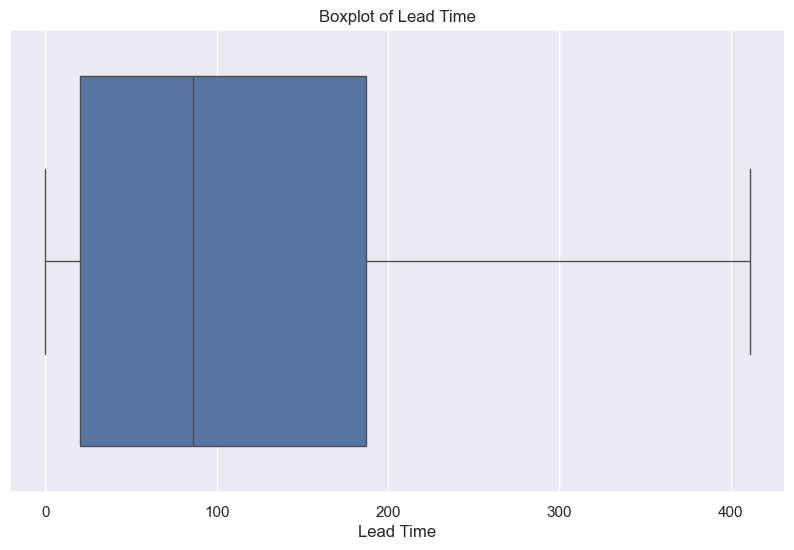

In [19]:
eda.graficarBoxplot("Lead Time")

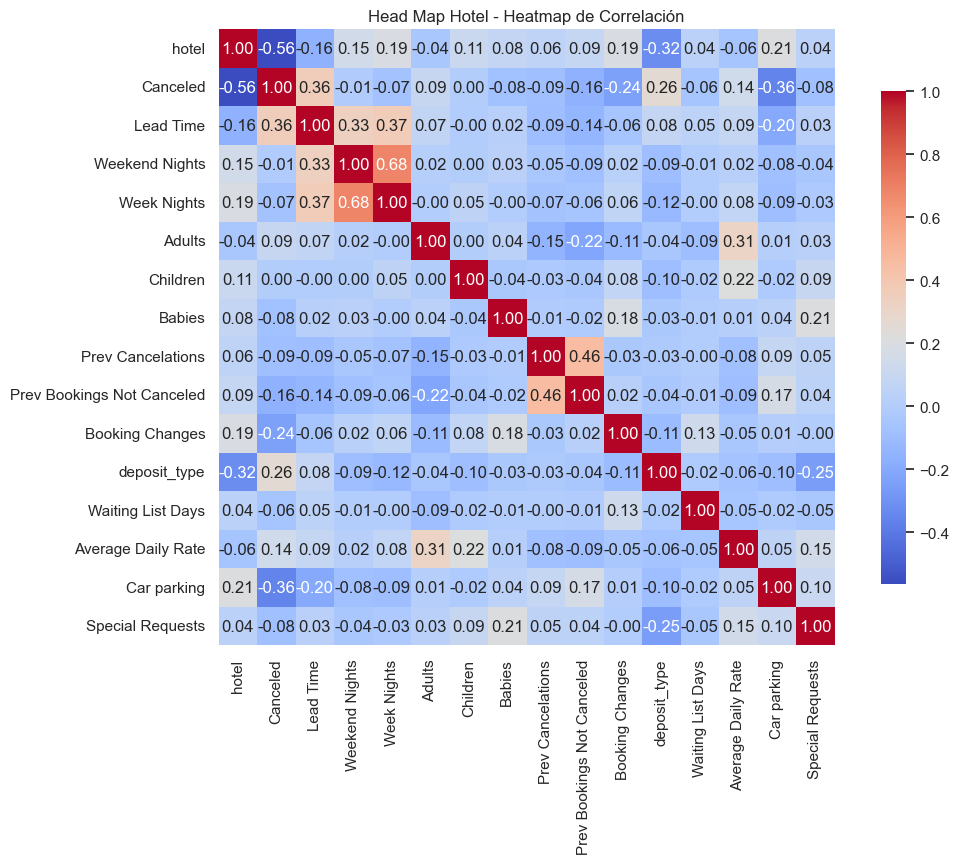

In [21]:
eda.graficarHeatmap("Head Map Hotel")

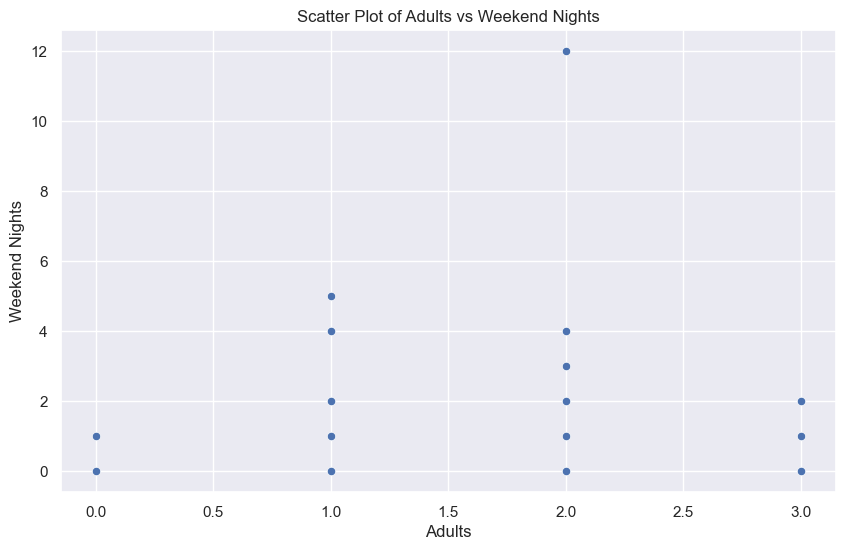

In [22]:
eda.graficarScatter("Adults", "Weekend Nights")